<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/16_2_2_THEORY_CNN_as_feature_extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
input_shape = (299, 299)

In [4]:
# move the images from /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/ to ./lfw-deepfunneled/
!mv /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/ ./

Streaming output truncated to the last 5000 lines.
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Enrique_Bolanos/Enrique_Bolanos_0004.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Enrique_Bolanos/Enrique_Bolanos_0005.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Enrique_Bolanos/Enrique_Bolanos_0001.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Kathryn_Bigelow/Kathryn_Bigelow_0001.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Kathryn_Bigelow/Kathryn_Bigelow_0002.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/William_Macy/William_Macy_0003.jpg': Read-only file system
mv: cannot remove '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/William_Macy

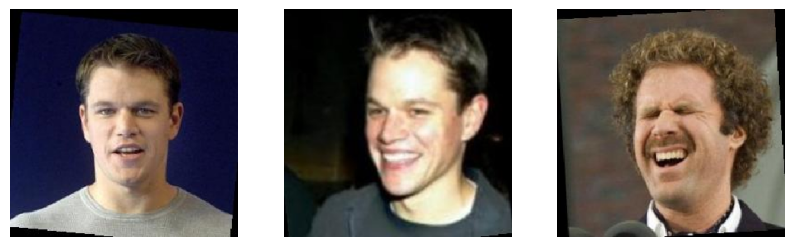

In [5]:
matt_1 = image.load_img("lfw-deepfunneled/Matt_Damon/Matt_Damon_0001.jpg", target_size=input_shape)
matt_2 = image.load_img("lfw-deepfunneled/Matt_Damon/Matt_Damon_0002.jpg", target_size=input_shape)
will_1 = image.load_img("lfw-deepfunneled/Will_Ferrell/Will_Ferrell_0001.jpg", target_size=input_shape)

loaded_imgs = [matt_1, matt_2, will_1]

plt.figure(figsize=(10, 10))
for i, img in enumerate(loaded_imgs):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(np.asarray(img).astype("uint8"))
    plt.axis("off")

In [6]:
model = InceptionV3(
    input_shape=input_shape + (3,),
    weights='imagenet',
    include_top=False,
    pooling='avg',
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [7]:
model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [8]:
x = np.array([image.img_to_array(img) for img in loaded_imgs])
x = preprocess_input(x)
features = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


In [9]:
features.shape

(3, 2048)

In [10]:
print(cosine_similarity(features[0].reshape(1, -1), features[1:]))

[[0.7356491  0.65811443]]


In [11]:
!wget https://www.anred.org/wp-content/uploads/2021/11/trueno-w.jpg

--2026-04-19 21:03:40--  https://www.anred.org/wp-content/uploads/2021/11/trueno-w.jpg
Resolving www.anred.org (www.anred.org)... 91.226.176.136
Connecting to www.anred.org (www.anred.org)|91.226.176.136|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43971 (43K) [image/jpeg]
Saving to: ‘trueno-w.jpg’

trueno-w.jpg        100%[===================>]  42.94K   116KB/s    in 0.4s    

2026-04-19 21:03:41 (116 KB/s) - ‘trueno-w.jpg’ saved [43971/43971]



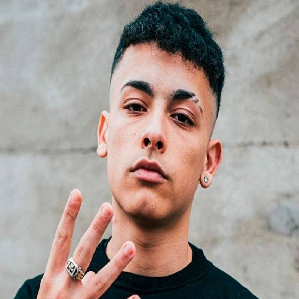

In [12]:
trueno = image.load_img("trueno-w.jpg", target_size=input_shape)
trueno

In [13]:
x = image.img_to_array(trueno)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
features_trueno = model.predict(x)


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [14]:
print(cosine_similarity(features_trueno, features))

[[0.5919063  0.58954424 0.55127424]]


In [15]:
img_labels = []
img_paths = []
for (dirpath, dirnames, filenames) in os.walk("lfw-deepfunneled"):
    for file_name in filenames:
        # Get full path to the file
        file_full_path = os.path.join(dirpath, file_name)
        img_paths.append(file_full_path)

        # Get person name for the given image
        name = " ".join(file_name.split("_")[:-1])
        img_labels.append(name)


batch_size = 128
img_features = []
for i in tqdm(range(0, len(img_paths), batch_size)):
    batch_paths = img_paths[i:i + batch_size]
    batch_imgs = [
        image.load_img(img_path, target_size=input_shape)
        for img_path in batch_paths
    ]
    x = np.array([image.img_to_array(img) for img in batch_imgs])
    x = preprocess_input(x)

    batch_features = model.predict(x, batch_size=batch_size)
    img_features.extend(list(batch_features))

img_features = np.asarray(img_features)
img_labels = np.asarray(img_labels)
img_paths = np.asarray(img_paths)

img_features.shape, img_labels.shape, img_paths.shape

  0%|          | 0/104 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1

((13233, 2048), (13233,), (13233,))

In [16]:
%%time
sim = cosine_similarity(features_trueno, img_features)[0]
sim_argsort = np.argsort(sim)[::-1]


CPU times: user 87.3 ms, sys: 21.8 ms, total: 109 ms
Wall time: 100 ms


In [17]:
for i in range(5):
    label = img_labels[sim_argsort[i]]
    similarity = sim[sim_argsort[i]]
    print(f"- Matched subject '{label}' with similarity {similarity:.4f}")


- Matched subject 'Robert Gallo' with similarity 0.7350
- Matched subject 'Alexandra Rozovskaya' with similarity 0.7312
- Matched subject 'Brad Miller' with similarity 0.7250
- Matched subject 'Winona Ryder' with similarity 0.7238
- Matched subject 'Jennifer Lopez' with similarity 0.7220


In [18]:
!wget -O "george.jpeg" "https://cloudfront-us-east-1.images.arcpublishing.com/infobae/XW4S75Y7IBECTEY25SZYHZU76A.jpeg"

--2026-04-19 21:07:06--  https://cloudfront-us-east-1.images.arcpublishing.com/infobae/XW4S75Y7IBECTEY25SZYHZU76A.jpeg
Resolving cloudfront-us-east-1.images.arcpublishing.com (cloudfront-us-east-1.images.arcpublishing.com)... 13.33.88.62, 13.33.88.16, 13.33.88.15, ...
Connecting to cloudfront-us-east-1.images.arcpublishing.com (cloudfront-us-east-1.images.arcpublishing.com)|13.33.88.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 698750 (682K) [image/jpeg]
Saving to: ‘george.jpeg’

george.jpeg         100%[===================>] 682.37K  --.-KB/s    in 0.007s  

2026-04-19 21:07:07 (96.7 MB/s) - ‘george.jpeg’ saved [698750/698750]



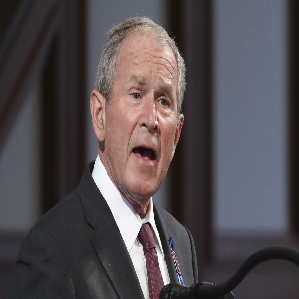

In [19]:
george = image.load_img("george.jpeg", target_size=input_shape)
george

In [20]:
x = image.img_to_array(george)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
features_george = model.predict(x)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [21]:
%%time
sim = cosine_similarity(features_george, img_features)[0]
sim_argsort = np.argsort(sim)[::-1]


CPU times: user 83.8 ms, sys: 21.7 ms, total: 105 ms
Wall time: 100 ms


In [22]:
img_paths[sim_argsort[i]]

np.str_('lfw-deepfunneled/Sean_OKeefe/Sean_OKeefe_0002.jpg')

In [23]:
for i in range(10):
    label = img_labels[sim_argsort[i]]
    similarity = sim[sim_argsort[i]]
    print(f"- Matched subject '{label}' with similarity {similarity:.4f}")


- Matched subject 'Goran Persson' with similarity 0.8318
- Matched subject 'Martin Frost' with similarity 0.8289
- Matched subject 'Spike Helmick' with similarity 0.8262
- Matched subject 'George W Bush' with similarity 0.8223
- Matched subject 'Sean OKeefe' with similarity 0.8208
- Matched subject 'Donald Rumsfeld' with similarity 0.8201
- Matched subject 'George W Bush' with similarity 0.8169
- Matched subject 'George W Bush' with similarity 0.8166
- Matched subject 'Jean Chretien' with similarity 0.8151
- Matched subject 'George W Bush' with similarity 0.8149
